# 05b - Trainable Self-Attention: Queries, Keys and Values

**Lecture goal:** take the parameter-free mechanism of notebook `05a` and give it something to learn. We'll introduce the three trainable weight matrices `W_query`, `W_key` and `W_value`, work out why the scores get divided by the square root of the key dimension, and finish with the mechanism wrapped in a reusable `nn.Module` - at which point we'll have built, in full, the operation that sits at the heart of every GPT.

This notebook is the slow companion to the second half of `05_self_attention.ipynb`, exactly as `05a_simplified_attention.ipynb` is to the first half. Notebook 05 covers this ground in a handful of cells on its way to notebook 06; here we stop at every step and ask why it's the step it is.

## Where we left off

Notebook `05a` built attention from nothing. Six embedding vectors went in, six **context vectors** came out, and the whole mechanism reduced to three lines:

```python
attn_scores = inputs @ inputs.T
attn_weights = torch.softmax(attn_scores, dim=-1)
all_context_vecs = attn_weights @ inputs
```

It also ended on the reason that isn't good enough. Every number in those three lines comes from the embeddings themselves, so there is nothing to train - and worse, a bare dot product between embeddings can only ever detect **semantic similarity**. Recall the example:

> The cat sat on the mat because it is **warm**.

`"warm"` needs to attend to `"mat"`, but the two words don't mean similar things, so their embeddings don't align, so the mechanism misses the one connection that matters. Relevance is not the same as similarity, and a fixed dot product can only measure the latter.

## The fix, in one sentence

**Stop comparing the raw embeddings. Project each one through a learned matrix first, and let training decide what the projection should be.**

That's the entire idea of this notebook. Everything else - three matrices instead of one, the scaling factor, the class at the end - is detail hanging off that sentence.

Why does it work? Because a projection is a change of viewpoint. Under the identity projection, `"warm"` and `"mat"` point in unrelated directions. But there may exist some linear map under which they *do* align - one that, loosely, extracts "what kind of thing is being described" from one vector and "what kind of description does this thing attract" from the other. Nobody has to find that map by hand. It's a matrix of ordinary parameters, gradient descent tunes it like any other, and it gets tuned toward whatever makes the next-token prediction better. Having read enough text, the model discovers that mats are the sort of thing called warm.

The name for this mechanism, once the scaling factor of Step 4 is included, is **scaled dot-product attention**. It's what the 2017 paper introduced and what every model in this series uses from here on.

## The same toy example

We keep the six tokens and the same three-dimensional embeddings from `05a`, so that every intermediate number can be compared against the version without trainable weights.

In [1]:
import torch

inputs = torch.tensor([
    [0.43, 0.15, 0.89],  # Your     x^(1)
    [0.55, 0.87, 0.66],  # journey  x^(2)
    [0.57, 0.85, 0.64],  # starts   x^(3)
    [0.22, 0.58, 0.33],  # with     x^(4)
    [0.77, 0.25, 0.10],  # one      x^(5)
    [0.05, 0.80, 0.55],  # step     x^(6)
])

words = ["Your", "journey", "starts", "with", "one", "step"]

print("inputs.shape:", inputs.shape, " (6 tokens, 3 embedding dimensions)")

inputs.shape: torch.Size([6, 3])  (6 tokens, 3 embedding dimensions)


## Three projections, three roles

Here's the first thing that surprises people: we don't introduce *one* learned projection, we introduce **three**. Each input embedding gets turned into three different vectors, and each one has a job.

- The **query** is the vector a token uses to *ask*. When we're computing the context vector for `"journey"`, `"journey"`'s query says what sort of information it's looking for from the rest of the sentence.
- The **key** is the vector a token uses to *advertise itself*. Every token publishes one, and queries are matched against keys.
- The **value** is the vector a token actually *contributes* once it's been matched. It's the payload - the thing that gets blended into the context vector.

The names come from information retrieval, and the analogy is worth spelling out because it makes the three-way split feel inevitable rather than arbitrary. Picture a filing cabinet. The **query** is a sticky note with the topic you're researching. The **keys** are the labels on the folder tabs - what you check the sticky note against. Once a tab looks like a match, you don't keep the tab; you pull out what's *inside* the folder, and that's the **value**. Tab and contents are deliberately different objects: one is written to be found, the other to be useful once found. And critically, you're rarely after just one folder - you take a little from several tabs that partially matched, in proportion to how well each one matched. That's not a simplification of the mechanism for the sake of the analogy; it *is* the mechanism.

Self-attention runs exactly this search, six times over, with every token taking a turn as the researcher and every token - including the researcher itself - sitting in the cabinet as a folder.

*This analogy is adapted from Jay Alammar's [The Illustrated GPT-2](https://jalammar.github.io/illustrated-gpt2/).*

### Why not use one vector for all three?

Because the three jobs pull in different directions, and a single vector would have to compromise between them. What makes a token a good *match* for a query need not be what makes it *useful* to hand over. A verb might be found by its grammatical role and yet contribute its semantic content. With separate projections the model can learn to compare tokens along one set of features while blending them along another. Reusing the raw embedding for all three - which is precisely what `05a` did - forces those to be the same thing.

There's a second, purely mechanical consequence, and it's the one that fixes the `"warm"`/`"mat"` problem. Because queries and keys are produced by *different* matrices, the score a query gives a key is no longer the same as the score you'd get by swapping their roles. The comparison becomes directional, which is what "relevance" actually is - `"warm"` needs `"mat"` far more than `"mat"` needs `"warm"`. We'll see that asymmetry appear in the numbers shortly.

### The "self" in self-attention

All three projections are computed from the *same* input sequence. There's no second sentence anywhere - the sequence produces its own queries, its own keys and its own values, and attends to itself. That's the whole reason for the word. Contrast it with the cross-attention of notebook 05's history section, where a decoder's queries were matched against an encoder's keys, i.e. one sequence looking at another.

### A concrete illustration: "cat" wearing three faces

Before returning to the six-token `"journey"` example, it's worth seeing why one vector can't serve three roles, on a sentence small enough that the embedding dimensions mean something.

Take `"The cat sat"` and hand-design a 4-dimensional embedding where each axis is a linguistic feature - how determiner-like a word is, how noun-like, how verb-like, how animate:

| word | determiner | noun | verb | animate |
|---|---|---|---|---|
| The | 1.0 | 0.0 | 0.0 | 0.0 |
| cat | 0.1 | 1.0 | 0.0 | 0.8 |
| sat | 0.0 | 0.1 | 1.0 | 0.0 |

`"cat"` sits close to pure "noun, animate." Project that one vector through three different `(4, 3)` matrices and see what comes back.

In [2]:
torch.manual_seed(7)

words_ex = ["The", "cat", "sat"]
embeddings_ex = torch.tensor([
    [1.0, 0.0, 0.0, 0.0],   # The - determiner
    [0.1, 1.0, 0.0, 0.8],   # cat - animate noun
    [0.0, 0.1, 1.0, 0.0],   # sat - verb
])

d_in_ex, d_out_ex = 4, 3
W_q_ex = torch.rand(d_in_ex, d_out_ex) * 0.5
W_k_ex = torch.rand(d_in_ex, d_out_ex) * 0.5
W_v_ex = torch.rand(d_in_ex, d_out_ex) * 0.5

Q_ex = embeddings_ex @ W_q_ex
K_ex = embeddings_ex @ W_k_ex
V_ex = embeddings_ex @ W_v_ex

for word, q, k, v in zip(words_ex, Q_ex, K_ex, V_ex):
    print(f"{word:>5}   query {[round(x, 3) for x in q.tolist()]}")
    print(f"        key   {[round(x, 3) for x in k.tolist()]}")
    print(f"        value {[round(x, 3) for x in v.tolist()]}")
    print()

  The   query [0.267, 0.099, 0.33]
        key   [0.143, 0.103, 0.223]
        value [0.26, 0.297, 0.44]

  cat   query [0.696, 0.468, 0.466]
        key   [0.359, 0.673, 0.337]
        value [0.568, 0.71, 0.484]

  sat   query [0.136, 0.327, 0.204]
        key   [0.503, 0.09, 0.445]
        value [0.459, 0.374, 0.319]



`"cat"`'s embedding is the same four numbers everywhere it's used, but its query, key and value land in three unrelated corners of 3-dimensional space. Nothing in the arithmetic ties them together, because three independent matrices produced them - there was never a reason for `query_cat` to resemble `key_cat`, let alone the original embedding. That's the abstract argument from the section above, made concrete: one source vector, three roles, three matrices standing between them.

*This illustration follows the worked example in Michael Brenndoerfer's [Query, Key, Value: The Foundation of Transformer Attention](https://mbrenndoerfer.com/writing/query-key-value-attention-mechanism), which walks the same sentence through scoring and aggregation with the same kind of interpretable, hand-picked embedding.*

## Two dimensions to name first

Before any matrices, two numbers:

- `d_in` - the width of each input embedding. Ours is 3, read straight off `inputs.shape[1]`.
- `d_out` - the width of the query, key and value vectors we're about to produce. We'll pick 2.

Each weight matrix is therefore `(d_in, d_out)` = `(3, 2)`: it eats a 3-number embedding and emits a 2-number projection.

Choosing `d_out = 2` when `d_in = 3` is a deliberate teaching choice - keeping the two different means you can't confuse them when reading shapes, and it makes the projection visibly a *change of space* rather than a reshuffle within one. In real models the two are usually equal: GPT-2 small runs 768 in and 768 out. (In notebook 06, multi-head attention will split that 768 across heads, so each individual head does end up with `d_out < d_in` - but that's a different reason.)

We'll also single out `x_2`, the embedding of `"journey"`, and follow it all the way through before doing anything with the whole batch. Same tactic as `05a`: one token completely, then generalise.

In [3]:
x_2 = inputs[1]           # "journey"
d_in = inputs.shape[1]    # 3
d_out = 2                 # chosen

print("x_2   :", x_2)
print("d_in  :", d_in)
print("d_out :", d_out)

x_2   : tensor([0.5500, 0.8700, 0.6600])
d_in  : 3
d_out : 2


## The three weight matrices

Now the parameters. Three matrices of shape `(3, 2)`, filled with random numbers.

Random, because that is genuinely how they start. Nobody knows what a good query projection looks like; the model finds one by descending the loss. This is the same story as the embedding table in notebook 04 - random initialisation, meaning acquired entirely through training - and it's worth noticing how much of a neural network turns out to be that story repeated.

We wrap them in `torch.nn.Parameter`, which is PyTorch's way of saying "this tensor is a learnable parameter of a model." A `Parameter` is an ordinary tensor with one extra property: when it's assigned to an attribute of an `nn.Module`, the module registers it, `model.parameters()` picks it up, and the optimizer therefore updates it. That last part is what makes the whole notebook work.

We pass `requires_grad=False` here purely to keep the printed output clean - there's no training loop in this notebook, so there's no reason to build a gradient graph. In the real class at the end of the notebook we'll leave it at its default of `True`.

In [4]:
torch.manual_seed(123)

W_query = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_key   = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)
W_value = torch.nn.Parameter(torch.rand(d_in, d_out), requires_grad=False)

print("W_query:", tuple(W_query.shape))
print(W_query)
print()
print("W_key:", tuple(W_key.shape))
print(W_key)
print()
print("W_value:", tuple(W_value.shape))
print(W_value)

W_query: (3, 2)
Parameter containing:
tensor([[0.2961, 0.5166],
        [0.2517, 0.6886],
        [0.0740, 0.8665]])

W_key: (3, 2)
Parameter containing:
tensor([[0.1366, 0.1025],
        [0.1841, 0.7264],
        [0.3153, 0.6871]])

W_value: (3, 2)
Parameter containing:
tensor([[0.0756, 0.1966],
        [0.3164, 0.4017],
        [0.1186, 0.8274]])


Six numbers each, eighteen in total - the entire learnable content of our attention layer. Scale that up: GPT-2 small has `768 x 768` per matrix, three matrices per head-group, twelve layers. The arithmetic below is unchanged; only the shapes grow.

Two things not to confuse, because the names are similar and the distinction matters for the rest of the notebook:

| name | shape | what it is |
|---|---|---|
| `W_query` | `(d_in, d_out)` | a **weight matrix** - learned, shared by every token |
| `query_2` | `(d_out,)` | a **query vector** - one token's projection, recomputed for every input |

The matrices are the parameters; the vectors are activations that the parameters produce.

## Projecting one token

Applying a projection is a single matrix multiplication: a `(3,)` vector times a `(3, 2)` matrix gives a `(2,)` vector. Here are `"journey"`'s three projections.

In [5]:
query_2 = x_2 @ W_query
key_2   = x_2 @ W_key
value_2 = x_2 @ W_value

print("x_2     :", x_2, "  shape", tuple(x_2.shape))
print("query_2 :", query_2, "     shape", tuple(query_2.shape))
print("key_2   :", key_2, "     shape", tuple(key_2.shape))
print("value_2 :", value_2, "     shape", tuple(value_2.shape))

x_2     : tensor([0.5500, 0.8700, 0.6600])   shape (3,)
query_2 : tensor([0.4306, 1.4551])      shape (2,)
key_2   : tensor([0.4433, 1.1419])      shape (2,)
value_2 : tensor([0.3951, 1.0037])      shape (2,)


Same operation, batched. `inputs` is `(6, 3)`, each weight matrix is `(3, 2)`, so `inputs @ W` is `(6, 2)`: one projected vector per token, stacked as rows. As always in this series, **rows are tokens**.

Note that `"journey"` needs a query only because it's the token we happen to be asking about - but every token needs a key and a value, since every token is a folder in the cabinet. We compute all three for everyone anyway; it's one matmul either way, and every token gets its turn as the query soon enough.

In [6]:
queries = inputs @ W_query
keys    = inputs @ W_key
values  = inputs @ W_value

print("queries.shape:", tuple(queries.shape))
print("keys.shape   :", tuple(keys.shape))
print("values.shape :", tuple(values.shape))
print()
print("keys:")
print(keys)
print()
print("Row 1 of queries equals the query_2 we computed by hand?",
      torch.allclose(queries[1], query_2))

queries.shape: (6, 2)
keys.shape   : (6, 2)
values.shape : (6, 2)

keys:
tensor([[0.3669, 0.7646],
        [0.4433, 1.1419],
        [0.4361, 1.1156],
        [0.2408, 0.6706],
        [0.1827, 0.3292],
        [0.3275, 0.9642]])

Row 1 of queries equals the query_2 we computed by hand? True


## Step 1: Attention scores

From here on the shape of the computation is the one `05a` already established - score, normalize, weight-and-sum. The only change is *which vectors* go into each step.

The score between a query and a key is their dot product, for exactly the reason it was in `05a`: the dot product measures alignment, and alignment is now "does this key answer that query?" rather than "do these two words mean the same thing." The operation is identical; what it means has changed, because the vectors it's applied to are learned.

Start with a single score - `"journey"` querying `"journey"` itself, which in the matrix will be entry `(1, 1)`.

In [7]:
keys_2 = keys[1]
attn_score_22 = query_2.dot(keys_2)

print("score(query 'journey', key 'journey') =", attn_score_22)

score(query 'journey', key 'journey') = tensor(1.8524)


A first sign that something has genuinely changed: in `05a` a token always scored highest against itself, because a vector is perfectly aligned with itself. That guarantee is gone. `query_2` and `key_2` come from different matrices, so they're different vectors, and their dot product carries no special status. As it turns out the self-score above is still the largest of the six, but that's an accident of these particular random matrices, not something the mechanism enforces. A token attending mostly to something *other* than itself is now not only possible but usually the point.

Now all six scores for the `"journey"` query - one dot product against each key, which is `query_2 @ keys.T`.

In [8]:
attn_scores_2 = query_2 @ keys.T

for word, score in zip(words, attn_scores_2):
    print(f"{word:>8}: {score:.4f}")
print()
print("shape:", tuple(attn_scores_2.shape))

    Your: 1.2705
 journey: 1.8524
  starts: 1.8111
    with: 1.0795
     one: 0.5577
    step: 1.5440

shape: (6,)


### Every query at once

Stack the queries and it's one matrix multiplication for all 36 scores:

```python
attn_scores = queries @ keys.T
```

`(6, 2) @ (2, 6) -> (6, 6)`, and the reading of the result is the same as in `05a`:

> **Row `i`, column `j`** is the score from query token `i` to key token `j`.

Read it as rows: each row is one token's opinion of the whole sentence.

In [9]:
attn_scores = queries @ keys.T

print(attn_scores)
print()
print("Row 1 matches the by-hand 'journey' scores?",
      torch.allclose(attn_scores[1], attn_scores_2))

tensor([[0.9231, 1.3545, 1.3241, 0.7910, 0.4032, 1.1330],
        [1.2705, 1.8524, 1.8111, 1.0795, 0.5577, 1.5440],
        [1.2544, 1.8284, 1.7877, 1.0654, 0.5508, 1.5238],
        [0.6973, 1.0167, 0.9941, 0.5925, 0.3061, 0.8475],
        [0.6114, 0.8819, 0.8626, 0.5121, 0.2707, 0.7307],
        [0.8995, 1.3165, 1.2871, 0.7682, 0.3937, 1.0996]])

Row 1 matches the by-hand 'journey' scores? True


### The score matrix is no longer symmetric

Worth stopping on, because it's the concrete payoff of using two separate matrices instead of one.

In `05a` the score matrix was symmetric: entry `(i, j)` was `x_i . x_j`, and dot products don't care about order. Here entry `(i, j)` is `(x_i W_q) . (x_j W_k)` while entry `(j, i)` is `(x_j W_q) . (x_i W_k)` - different matrices applied to different vectors, so no reason at all for the two to agree.

In [10]:
print("Symmetric?", torch.allclose(attn_scores, attn_scores.T))
print()
i, j = 1, 4
print(f"score({words[i]} -> {words[j]}) = {attn_scores[i, j]:.4f}")
print(f"score({words[j]} -> {words[i]}) = {attn_scores[j, i]:.4f}")

Symmetric? False

score(journey -> one) = 0.5577
score(one -> journey) = 0.8819


That's the mechanism becoming able to express one-way relevance. `"warm"` may need `"mat"` badly while `"mat"` barely registers `"warm"`; a symmetric score matrix cannot represent that, and this one can.

## Step 2: Scaling by the square root of the key dimension

Before the softmax comes the step that puts the "scaled" in scaled dot-product attention: divide every score by the square root of the key dimension.

```python
d_k = keys.shape[-1]
attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)
```

`d_k` is 2 in our example and 64 in a GPT-2 attention head. This looks like a magic constant, and it isn't - there are two distinct reasons for it, and they're worth separating because they're usually run together.

### Reason 1: softmax gets sharper as its inputs get bigger

Softmax is not scale-invariant. Multiply its input by a constant greater than 1 and the output doesn't stay put - it concentrates. Large inputs produce a *peaky* distribution: nearly all the probability mass on one entry, nearly zero everywhere else.

That's exactly the behaviour we *wanted* in `05a` when comparing softmax against divide-by-the-sum on `[1, 2, 3, 400]`. Here we're seeing its other face. A little sharpening is good; too much and attention collapses to winner-take-all, which throws away the distributed focus that made the mechanism useful in the first place. Watch what a factor of 8 does.

In [11]:
tensor = torch.tensor([0.1, -0.2, 0.3, -0.2, 0.5])

print("softmax(x)    :", torch.softmax(tensor, dim=-1))
print("softmax(8 * x):", torch.softmax(tensor * 8, dim=-1))

softmax(x)    : tensor([0.1925, 0.1426, 0.2351, 0.1426, 0.2872])
softmax(8 * x): tensor([0.0326, 0.0030, 0.1615, 0.0030, 0.8000])


The unscaled version spreads attention across all five entries - the largest gets about 29%, the smallest still 14%. Multiply by 8 and the largest takes 80% while the two smallest collapse to 0.3%. Same relative ordering, completely different distribution.

And the damage isn't only that the model stops looking at more than one token. **A peaky softmax has tiny gradients.** Softmax's derivative involves terms like `p(1 - p)`, which goes to zero as `p` approaches 0 or 1 - so once the distribution saturates, almost no learning signal flows back through it. The layer freezes: the attention pattern it happens to have at that moment is roughly the one it keeps. This is the vanishing-gradient problem, arriving through a door people don't always watch.

### Reason 2: dot products grow with dimension

So why does `sqrt(d_k)` specifically, rather than any other damping constant?

Because we can say precisely how big the scores tend to get. Take two random vectors of dimension `d` whose components are independent with variance 1. Their dot product is a sum of `d` independent products, and variances of independent terms add - so the dot product has variance `d`, and typical magnitude around `sqrt(d)`. Nothing about attention here; it's just what happens when you sum `d` random terms.

The consequence is unpleasant. Widen the model - the thing you do to make it better - and the raw scores grow, so the softmax gets peakier, so the gradients shrink. Better models would train worse, purely as an artefact of the arithmetic.

Divide by `sqrt(d_k)` and the variance goes back to 1 for any `d`, because dividing by a constant `c` divides the variance by `c^2`, and `sqrt(d)^2 = d`. The scores then arrive at the softmax at the same typical scale whether `d_k` is 2 or 2048. Let's measure it rather than assert it.

In [12]:
torch.manual_seed(0)


def dot_product_variance(dim, num_trials=10_000):
    q = torch.randn(num_trials, dim)
    k = torch.randn(num_trials, dim)
    dots = (q * k).sum(dim=-1)
    return dots.var().item(), (dots / dim**0.5).var().item()


for dim in (5, 100, 1000):
    before, after = dot_product_variance(dim)
    print(f"dim = {dim:>4}:  variance before scaling = {before:9.3f}   after = {after:.3f}")

dim =    5:  variance before scaling =     5.051   after = 1.010
dim =  100:  variance before scaling =    99.309   after = 0.993


dim = 1000:  variance before scaling =   964.673   after = 0.965


The variance before scaling tracks the dimension almost exactly - about 5, about 100, about 1000 - and after dividing by `sqrt(d)` it lands near 1 in every case, whatever the dimension. (The wobble around 1 is sampling noise from using 10,000 trials rather than infinitely many.) That's the whole justification, and it's why the constant is a square root rather than anything else.

### Putting it together

Scale, then softmax, for the `"journey"` query.

In [13]:
d_k = keys.shape[-1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k**0.5, dim=-1)

print("d_k =", d_k, " scaling factor =", d_k**0.5)
print()
for word, w in zip(words, attn_weights_2):
    print(f"  {word:>8}: {w * 100:5.1f}%  {'#' * int(round(float(w) * 100))}")
print()
print("Sum:", attn_weights_2.sum())

d_k = 2  scaling factor = 1.4142135623730951

      Your:  15.0%  ###############
   journey:  22.6%  #######################
    starts:  22.0%  ######################
      with:  13.1%  #############
       one:   9.1%  #########
      step:  18.2%  ##################

Sum: tensor(1.)


Interpretable percentages again, and again reasonably spread rather than winner-take-all.

Don't read too much meaning into *which* words score highly here. Our weight matrices are random numbers from `torch.rand`, so these weights reflect nothing but a particular seed. In a trained model they'd encode real syntactic and semantic relationships; in this notebook they only demonstrate the machinery.

Now all six rows. `dim=-1` for the same reason as in `05a`: normalize across each row, so every query's weights sum to 1 independently.

In [14]:
attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)

print(attn_weights)
print()
print("Row sums:", attn_weights.sum(dim=-1))
print("Row 1 matches the by-hand weights?", torch.allclose(attn_weights[1], attn_weights_2))

tensor([[0.1551, 0.2104, 0.2059, 0.1413, 0.1074, 0.1799],
        [0.1500, 0.2264, 0.2199, 0.1311, 0.0906, 0.1820],
        [0.1503, 0.2256, 0.2192, 0.1315, 0.0914, 0.1819],
        [0.1591, 0.1994, 0.1962, 0.1477, 0.1206, 0.1769],
        [0.1610, 0.1949, 0.1923, 0.1501, 0.1265, 0.1752],
        [0.1557, 0.2092, 0.2048, 0.1419, 0.1089, 0.1794]])

Row sums: tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])
Row 1 matches the by-hand weights? True


A `6 x 6` matrix of percentages is easier to take in as a picture, so here is the full attention pattern - row = the querying token, column = the token being attended to.

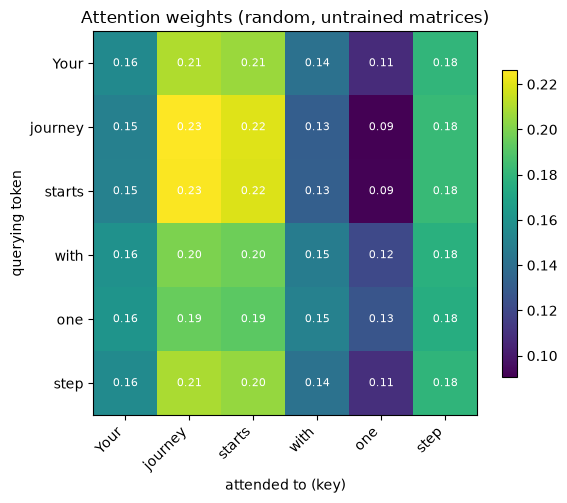

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(attn_weights.numpy(), cmap="viridis")

ax.set_xticks(range(6), words, rotation=45, ha="right")
ax.set_yticks(range(6), words)
ax.set_xlabel("attended to (key)")
ax.set_ylabel("querying token")
ax.set_title("Attention weights (random, untrained matrices)")

for i in range(6):
    for j in range(6):
        ax.text(j, i, f"{attn_weights[i, j]:.2f}", ha="center", va="center",
                color="white", fontsize=8)

fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

The last step, and the one that changes least from `05a`: scale and sum. Multiply each **value** vector by its attention weight and add them up.

The only difference is that word - **value**, not input. In `05a` the final line was `attn_weights @ inputs`, blending the raw embeddings. Now it's `attn_weights @ values`, blending the learned value projections. The keys decided *how much* of each token to take; the values decide *what* is actually taken. Tab versus contents.

Geometrically it's the same picture as before: each value vector is an arrow, each attention weight shrinks its arrow proportionally, and the shrunken arrows are laid end to end. Where you land is the context vector.

In [16]:
context_vec_2 = attn_weights_2 @ values

print("Context vector for 'journey' z^(2):", context_vec_2)
print("Its own value vector       value_2:", value_2)
print()
print("Contributions, term by term:")
for word, w, v in zip(words, attn_weights_2, values):
    print(f"  {word:>8}  {w:.4f} * {v.tolist()}")

Context vector for 'journey' z^(2): tensor([0.3061, 0.8210])
Its own value vector       value_2: tensor([0.3951, 1.0037])

Contributions, term by term:
      Your  0.1500 * [0.1855107694864273, 0.8811973333358765]
   journey  0.2264 * [0.3951329290866852, 1.0037459135055542]
    starts  0.2199 * [0.3879460394382477, 0.9830959439277649]
      with  0.1311 * [0.23928624391555786, 0.5493101477622986]
       one  0.0906 * [0.1491990089416504, 0.334585964679718]
      step  0.1820 * [0.3221239149570465, 0.7862914800643921]


Note the shape: `z^(2)` has `d_out = 2` components, not `d_in = 3`. Attention preserves the *number* of vectors - six in, six out, always - but the width is set by `d_out`. When `d_in` and `d_out` are equal, as in real models, this is easy to overlook; making them differ here keeps it visible.

Since `d_out` is 2 we can plot the whole thing on flat paper: the six value vectors, and the context vector that the weighted sum lands on.

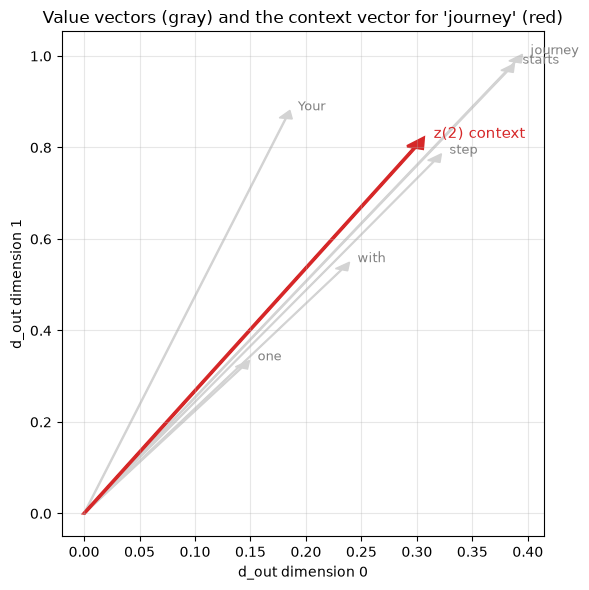

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))

for (vx, vy), word in zip(values.tolist(), words):
    ax.arrow(0, 0, vx, vy, head_width=0.012, color="lightgray", length_includes_head=True)
    ax.text(vx, vy, f"  {word}", fontsize=9, color="gray")

cx, cy = context_vec_2.tolist()
ax.arrow(0, 0, cx, cy, head_width=0.015, color="tab:red", length_includes_head=True, linewidth=2)
ax.text(cx, cy, "  z(2) context", fontsize=11, color="tab:red")

ax.set_xlabel("d_out dimension 0")
ax.set_ylabel("d_out dimension 1")
ax.set_title("Value vectors (gray) and the context vector for 'journey' (red)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The red arrow sits inside the cloud of gray ones - it has to, being a weighted average of them with positive weights summing to 1 - pulled toward whichever values earned the most attention.

That containment has a name: because the weights are non-negative and sum to 1, every context vector lands in the **convex hull** of the value vectors - the smallest convex region containing all of them. Attention can move a token's representation anywhere inside that region by changing the weights, but it can never step outside it. Whatever isn't present in some value vector's contribution, no context vector can manufacture from nothing.

### All six context vectors

One matrix multiplication: `(6, 6) @ (6, 2) -> (6, 2)`.

In [18]:
all_context_vecs = attn_weights @ values

print(all_context_vecs)
print()
print("shape:", tuple(all_context_vecs.shape))
print("Row 1 matches the by-hand context vector?",
      torch.allclose(all_context_vecs[1], context_vec_2))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]])

shape: (6, 2)
Row 1 matches the by-hand context vector? True


## The whole mechanism, in one formula and four lines

Everything above collapses to the expression you'll see in every paper on the subject:

```
Z = softmax( Q K^T / sqrt(d_k) ) V
```

and, in code, to four lines:

```python
queries = inputs @ W_query          # (6, 3) @ (3, 2) -> (6, 2)
keys    = inputs @ W_key            # (6, 3) @ (3, 2) -> (6, 2)
values  = inputs @ W_value          # (6, 3) @ (3, 2) -> (6, 2)

attn_scores  = queries @ keys.T                                   # (6, 6)
attn_weights = torch.softmax(attn_scores / d_k**0.5, dim=-1)      # (6, 6)
context_vecs = attn_weights @ values                              # (6, 2)
```

Read the pipeline once from left to right and every symbol should now have a reason attached:

| stage | operation | why |
|---|---|---|
| project | `x @ W_q`, `x @ W_k`, `x @ W_v` | learn *what to compare* and *what to contribute*, instead of hard-coding both to the raw embedding |
| score | `Q @ K.T` | dot product measures alignment: does this key answer that query? |
| scale | `/ sqrt(d_k)` | keep the score variance at 1 so softmax doesn't saturate and gradients don't vanish |
| normalize | `softmax(..., dim=-1)` | positive weights summing to 1, per query |
| blend | `@ V` | scale each value by its weight and sum: the context vector |

That is scaled dot-product attention, complete. Compare it to `05a`'s three lines and the family resemblance is unmistakable - the structure is the same mechanism, wearing learned projections.

## Packaging it into a module

Loose tensors were right for building intuition and wrong for building a model. GPT stacks this operation twelve times or more, and each copy needs its own parameters, tracked by the optimizer, movable to the GPU, saveable to disk. That's what `nn.Module` is for: put the parameters in `__init__`, put the computation in `forward`, and PyTorch handles the rest.

In [19]:
import torch.nn as nn


class SelfAttention_v1(nn.Module):
    def __init__(self, d_in, d_out):
        super().__init__()
        self.W_query = nn.Parameter(torch.rand(d_in, d_out))
        self.W_key   = nn.Parameter(torch.rand(d_in, d_out))
        self.W_value = nn.Parameter(torch.rand(d_in, d_out))

    def forward(self, x):
        queries = x @ self.W_query
        keys    = x @ self.W_key
        values  = x @ self.W_value

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        return attn_weights @ values

Nothing new in `forward` - it's the four lines, copied. Two details in `__init__` worth noting: `super().__init__()` must be called first or PyTorch's parameter registration never gets set up, and `requires_grad` is now left at its default of `True`, because this version is meant to be trained.

Calling the module is `sa_v1(inputs)`, not `sa_v1.forward(inputs)`. Both would run `forward`, but the first goes through `__call__`, which also fires the hooks PyTorch relies on internally - always use it.

Same seed as before, so it should reproduce the tensors we built by hand.

In [20]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)

print(sa_v1(inputs))
print()
print("Matches the step-by-step version?", torch.allclose(sa_v1(inputs), all_context_vecs))

tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)

Matches the step-by-step version? True


### A better version, using `nn.Linear`

There's a second way to write the same thing. A projection `x @ W` is precisely what a linear layer computes - and if we disable its bias term, `nn.Linear(d_in, d_out, bias=False)` *is* the projection, no more and no less. (We disable the bias because attention's derivation never asked for an offset; the standard implementation leaves it off, and notebook 08 will revisit `qkv_bias` when loading OpenAI's weights, which do include one.)

So why bother swapping? **Weight initialisation.** `torch.rand` draws uniformly from `[0, 1)` - every weight positive, with a mean of 0.5, which is a poor starting point for a deep network: activations drift and grow layer after layer. `nn.Linear` instead uses a scheme scaled by the layer's fan-in, giving zero-mean weights whose spread keeps the variance of activations roughly stable as signals pass through. On a six-token toy that's cosmetic; on a twelve-layer transformer it's the difference between converging and not. Getting good defaults for free is reason enough to prefer the layer.

The change also tidies the code: `self.W_key(x)` instead of `x @ self.W_key`.

In [21]:
class SelfAttention_v2(nn.Module):
    def __init__(self, d_in, d_out, qkv_bias=False):
        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key   = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, x):
        queries = self.W_query(x)
        keys    = self.W_key(x)
        values  = self.W_value(x)

        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)

        return attn_weights @ values


torch.manual_seed(789)
sa_v2 = SelfAttention_v2(d_in, d_out)

print(sa_v2(inputs))

tensor([[-0.0739,  0.0713],
        [-0.0748,  0.0703],
        [-0.0749,  0.0702],
        [-0.0760,  0.0685],
        [-0.0763,  0.0679],
        [-0.0754,  0.0693]], grad_fn=<MmBackward0>)


Different numbers from `v1` - as they must be. The two classes implement identical mathematics but start from different random weights, drawn from different distributions under different seeds. Different starting parameters, different outputs; nothing has gone wrong.

We can prove they're the same computation by transplanting one's weights into the other. The only subtlety is a transpose: `nn.Linear` stores its weight with shape `(d_out, d_in)` and computes `x @ W.T`, whereas `v1` stores `(d_in, d_out)` and computes `x @ W`. Line those up and the outputs must agree - to the last digit or two, where the two multiplication orders happen to round differently.

In [22]:
with torch.no_grad():
    sa_v1.W_query.copy_(sa_v2.W_query.weight.T)
    sa_v1.W_key.copy_(sa_v2.W_key.weight.T)
    sa_v1.W_value.copy_(sa_v2.W_value.weight.T)

print("v1 output:", sa_v1(inputs).tolist())
print("v2 output:", sa_v2(inputs).tolist())
print()
print("Identical once the weights match?", torch.allclose(sa_v1(inputs), sa_v2(inputs)))

v1 output: [[-0.07389025390148163, 0.07128990441560745], [-0.07481072098016739, 0.07030929625034332], [-0.07485618442296982, 0.07024165987968445], [-0.07600162923336029, 0.06845010817050934], [-0.0763276070356369, 0.06794282048940659], [-0.0754442811012268, 0.069304920732975]]
v2 output: [[-0.07389025390148163, 0.07128991186618805], [-0.07481072843074799, 0.07030929625034332], [-0.07485619187355042, 0.07024165987968445], [-0.07600162923336029, 0.06845010817050934], [-0.0763276144862175, 0.06794281303882599], [-0.0754442811012268, 0.069304920732975]]

Identical once the weights match? True


Same mechanism, better initialised. `v2` is the version everything from here on builds upon.


## Two dimensions, not one: `d_k` and `d_v`

We used a single `d_out = 2` for all three projections, and nearly every implementation does the same. The mechanism doesn't require it, though, and seeing why sharpens what each projection is for.

Queries and keys **must** share a width. They meet in a dot product, and a dot product between a 2-vector and a 3-vector isn't defined. That shared width is the `d_k` in `sqrt(d_k)`.

Values are never compared with anything. They are only scaled and summed, so their width is free. Call it `d_v`. Since a context vector is a weighted sum of value vectors, `d_v` is also the width of the output.

So the layer really has two knobs:

- **`d_k`** - the matching space. It sets how expressive query-key matching can be, and it sets the cost of the score matrix, which is `O(n^2 * d_k)`.
- **`d_v`** - the payload space. It sets the width of every context vector the layer emits.

Nothing stops us from pulling them apart:


In [23]:
d_k_demo, d_v_demo = 4, 3

torch.manual_seed(123)
W_q_demo = torch.rand(d_in, d_k_demo)
W_k_demo = torch.rand(d_in, d_k_demo)
W_v_demo = torch.rand(d_in, d_v_demo)

Q = inputs @ W_q_demo
K = inputs @ W_k_demo
V = inputs @ W_v_demo

A = torch.softmax(Q @ K.T / d_k_demo**0.5, dim=-1)
Z = A @ V

for name, t in [("inputs", inputs), ("Q", Q), ("K", K), ("V", V),
                ("weights", A), ("Z", Z)]:
    print(f"{name:>8}: {tuple(t.shape)}")


  inputs: (6, 3)
       Q: (6, 4)
       K: (6, 4)
       V: (6, 3)
 weights: (6, 6)
       Z: (6, 3)


It runs, and the shapes tell the story: the weight matrix is `6 x 6` regardless of either dimension - it only ever counts tokens - while the output inherits `d_v = 3`.

The full inventory, for `n` tokens of width `d_in`:

| tensor | shape | what it is |
|---|---|---|
| `inputs` | `(n, d_in)` | one embedding per token |
| `W_query`, `W_key` | `(d_in, d_k)` | the matching projections |
| `W_value` | `(d_in, d_v)` | the payload projection |
| `queries`, `keys` | `(n, d_k)` | what each token asks / advertises |
| `values` | `(n, d_v)` | what each token would contribute |
| `attn_scores`, `attn_weights` | `(n, n)` | every query against every key |
| context vectors | `(n, d_v)` | one output per token |

Two of these are worth committing to memory. The `(n, n)` in the middle is where the quadratic cost of attention lives, and the output being `(n, d_v)` - not `(n, d_in)` - is why width is a choice rather than a given.

In practice you'll almost never see `d_k` and `d_v` differ, for two reasons that both arrive in the next notebooks. Notebook 06 splits the embedding across `h` parallel heads and sets `d_k = d_v = d_in / h`, so that all heads together cost about what one full-width head would. Notebook 07 adds a **residual connection** around the attention block - the output is added back onto the input - and addition needs matching widths, which pins the total output width to `d_in`.

The ratio `d_k / d_in` is a compression factor. Choosing `d_k < d_in` forces the model to match on a squeezed summary of the embedding, which is a mild regularizer; choosing `d_k = d_in` keeps full expressiveness and pays for it in memory and compute.


## Attention as message passing

Step back from the algebra and the mechanism reads as a communication protocol. Every token broadcasts one message - its value vector - and every token receives one custom blend of all the broadcasts. The blend is decided by query-key compatibility, so the routing is **content-addressable**: a token gets information from whatever is relevant to it, not from whatever is nearby.

That's the actual break with what came before. A recurrent network moves information one step at a time, so a fact from token 1 reaches token 40 only by surviving 39 rewrites of the hidden state. A convolution sees a fixed local window and needs many stacked layers to widen it. Attention gives every position direct access to every other position in a single hop, and distance costs nothing - `"warm"` reaches `"mat"` in the same one step whether the words are adjacent or forty tokens apart.

The bill for that hop is the `(n, n)` in the shape table. Every pair gets scored, so cost grows with the square of the sequence length. That single fact is why context length is a headline number on every model release, and why so much research goes into approximating this matrix rather than computing it in full.


## What the mechanism can't do

Worth being clear about the limits of what we just built, because the rest of the architecture exists to patch them.

- **The projections are linear.** `Q`, `K` and `V` are matrix products of the embedding, nothing more, so a single attention layer can only express a fairly restricted family of matching functions. The fix is not a fancier attention - it's depth. Notebook 07 alternates attention with a nonlinear feed-forward network, and the composition is what gets the expressive power.
- **The formula knows nothing about order.** Permute the input rows and the output rows permute right along with them; nothing in `softmax(Q K^T / sqrt(d_k)) V` distinguishes "dog bites man" from "man bites dog". Position has to be smuggled in through the embeddings, which is exactly what the positional embeddings of notebook 04 were for.
- **No syntax, no hierarchy, no rules.** The model is handed no notion of subject, clause or phrase; every linguistic pattern in those attention weights has to be discovered from data. That's the mechanism's appetite for scale, and also its freedom - it isn't boxed in by anyone's grammar.

The flip side of that last point is reach. Nothing in the formula is about language. Vision transformers feed it image patches instead of tokens; multimodal models let text queries attend to image keys. Query-key-value matching turned out to be a general-purpose way to route information among a set of things, and language was only the first application.

*The framing in this section follows Michael Brenndoerfer's [Query, Key, Value: The Foundation of Transformer Attention](https://mbrenndoerfer.com/writing/query-key-value-attention-mechanism).*


## What's still missing

We've built real self-attention - the same operation GPT runs - but two pieces are needed before it can be dropped into a language model, and each gets its own treatment in notebook 06.

- **Causal masking.** Look at the attention matrix again: every token attends to every other token, including the ones that come *after* it. For next-token prediction that's cheating - the model would be reading the answer. Row `i` has to be blanked out beyond column `i`.
- **Multiple heads.** One set of `W_q`/`W_k`/`W_v` learns one notion of relevance. Real models run several in parallel - GPT-2 small runs 12 - so that one head can track grammatical agreement while another tracks subject matter, and their outputs are concatenated.

Notebook 06 adds both, plus dropout on the attention weights and support for batched input. But the core is what you just built; everything after this is a wrapper around these four lines.

## Recap

- The parameter-free mechanism of `05a` could only measure **semantic similarity**. The fix is to project each embedding through a **learned matrix** before comparing, so the model learns what relevance means instead of inheriting it from the embedding space.
- Three projections, three roles: the **query** asks, the **key** advertises, the **value** is what gets handed over. The filing-cabinet analogy - sticky note, folder tab, folder contents - is the reason for splitting one vector into three: what makes a token findable need not be what makes it useful.
- It's called **self**-attention because queries, keys and values all come from the same sequence.
- `d_in` is the embedding width, `d_out` the width of the projections; the weight matrices are `(d_in, d_out)`. Real models usually set them equal (768 for GPT-2 small).
- **Attention scores** are `queries @ keys.T`. Unlike in `05a` the matrix is **not symmetric**, because queries and keys come from different matrices - which is what lets attention express one-way relevance.
- Dividing by **`sqrt(d_k)`** exists for two reasons: softmax sharpens as its inputs grow, and a saturated softmax has near-zero gradients; and the variance of a dot product grows with dimension, so without the correction wider models would train worse. `sqrt(d_k)` is the constant that restores unit variance for any `d_k`.
- **Context vectors** are `attn_weights @ values` - the same scale-and-sum as `05a`, but blending the learned value projections rather than the raw embeddings. Six vectors in, six out, each of width `d_out`.
- The whole mechanism is `Z = softmax(Q K^T / sqrt(d_k)) V`, four lines of PyTorch, and this is exactly what "scaled dot-product attention" names.
- Wrap it in an `nn.Module` so the optimizer can find the parameters. Prefer `nn.Linear(..., bias=False)` over raw `nn.Parameter`: identical mathematics, far better default weight initialisation.
- Only **`d_k`** is forced on us - queries and keys have to meet in a dot product. **`d_v`** is free and sets the output width; implementations tie them together because multi-head splitting and residual connections both want them tied.
- Attention is **content-addressable message passing**: every token broadcasts a value, every token receives a custom blend, and any position reaches any other in one hop. The `(n, n)` score matrix is what that costs.
- The layer is linear, order-blind and structure-free on its own. Depth, positional embeddings and training data supply what it lacks.